# Задание 3. Эмпирическое распределение и p-value

Нужно промоделировать вычисление порога для заданного уровня значимости.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import motifs
from Bio.Seq import Seq

In [10]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA", "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC", "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
         "CAGGTTGGC"]

1. Генератор случайных последовательностей длины L = 9 с частотами генома человека (A/T : 0.295, G/C : 0.205)

In [11]:
def generate_sequence(L=9):
    nucleotides = ['A', 'T', 'G', 'C']
    probs = [0.295, 0.295, 0.205, 0.205] #частоты
    seq = ''.join(np.random.choice(nucleotides, size=L, p=probs))     #генерируем последовательность длины L
    return seq

In [12]:
def score_sequence(seq, pwm):
    score = 0
    for i, nucleotide in enumerate(seq):
        score += pwm[nucleotide][i]   # берём вес для нуклеотида на позиции i
    return score

In [14]:
sites_bio = [Seq(s) for s in sites]
m = motifs.create(sites_bio)
background = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}
ppm = m.counts.normalize(pseudocounts=1)
pwm = ppm.log_odds(background)
print(pwm)

        0      1      2      3      4      5      6      7      8
A:  -1.05   1.12  -1.05  -2.05  -2.05  -0.46   0.95  -0.46  -1.05
C:   1.29   0.06  -0.52  -1.52  -1.52   1.29  -1.52  -1.52   1.65
G:  -0.52  -1.52   1.65   1.94  -1.52  -1.52   0.48   1.65  -1.52
T:  -0.46  -2.05  -2.05  -2.05   1.41  -0.46  -2.05  -2.05  -1.05



In [15]:
N_bg = 100_000
background_scores = np.array([pwm.calculate(Seq(generate_sequence())) for _ in range(N_bg)]) #генерируем 100 000 фоновых последовательностей и считаем скоры

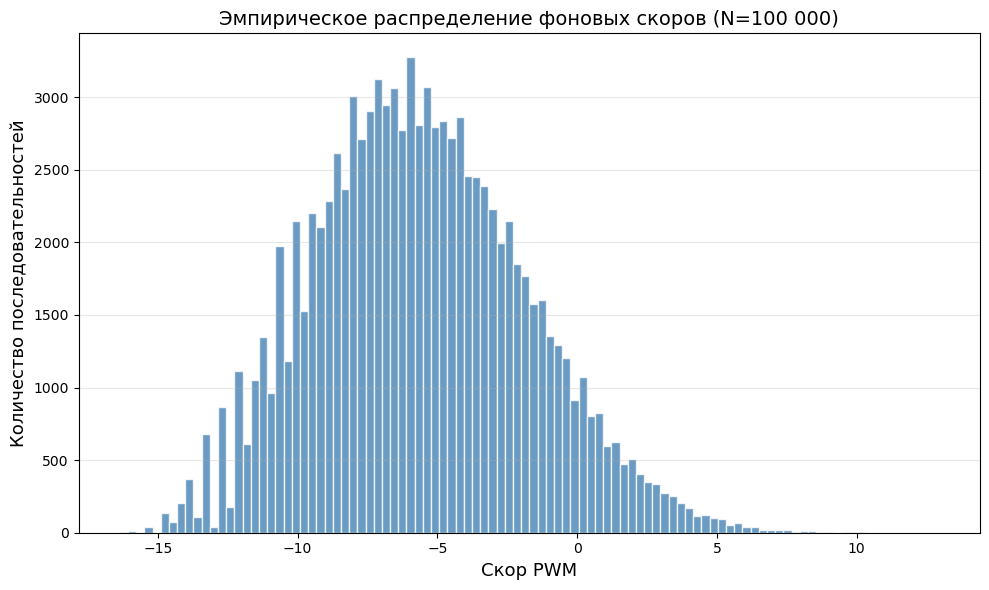

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(background_scores, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Скор PWM', fontsize=13)
plt.ylabel('Количество последовательностей', fontsize=13)
plt.title('Эмпирическое распределение фоновых скоров (N=100 000)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def get_pvalue(score): #функция, которая ищет p-value
    return np.sum(background_scores >= score) / len(background_scores)

In [18]:
target_pvalue = 1e-4
threshold = np.quantile(background_scores, 1 - target_pvalue)

print(f"Порог для p-value = 10⁻⁴: {threshold:.4f}")
print(f"Проверка: p-value у порога = {get_pvalue(threshold):.6f}")

Порог для p-value = 10⁻⁴: 9.7786
Проверка: p-value у порога = 0.000110
